# Pipeline Progress Notebook

This notebook documents the project pipeline and displays the final analyses. Reusable logic lives in `src/`, while expensive training and attribution commands remain commented unless they are intentionally rerun.

The final experimental record is stored in `outputs/`. Existing model outputs are loaded rather than overwritten.


In [ ]:
from pathlib import Path
import json
import os
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "README.md").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing README.md and src/.")


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data" / "processed"
BASELINE_DIR = PROJECT_ROOT / "outputs" / "baseline"

PROJECT_ROOT

## 1. Check Processed Data

Run this if you want to verify that the processed binary HateXplain files exist and inspect the current split counts.


In [2]:
summary_path = DATA_DIR / "hatexplain_binary_summary.csv"
summary = pd.read_csv(summary_path)
summary

,split,rows_after_mapping,hateful,non_hateful,identity_hateful,identity_non_hateful
0,train,10999,4748,6251,1506,3026
1,validation,1374,593,781,199,364
2,test,1376,594,782,181,347


If the processed CSV files are missing, regenerate them with the next cell.


In [3]:
# Run only if data/processed files are missing or you intentionally want to regenerate them.
# !python src/inspect_hatexplain.py

## 2. Train Baseline

Smoke tests are useful for checking that the code runs. Full baseline runs are the ones to use for real analysis.


In [4]:
# Small smoke test. This creates a new outputs/baseline/runN folder.
# !python src/train_baseline.py --quick --quick-size 512 --epochs 0.5 --batch-size 8 --local-files-only

In [5]:
# Full baseline training is kept as a reference only.
# !python src/train_baseline.py --epochs 3 --batch-size 16 --local-files-only


Saving this run to: outputs/baseline/run1
Loading weights: 100%|██████████████████████| 197/197 [00:00<00:00, 7825.86it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downst

## 3. Select the Official Baseline

The final analysis uses `outputs/baseline/run1`. Other baseline folders may contain smoke tests or exploratory runs and are not selected automatically.


In [6]:
def run_number(path: Path) -> int:
    if path.name.startswith("run") and path.name[3:].isdigit():
        return int(path.name[3:])
    return -1

runs = sorted([p for p in BASELINE_DIR.glob("run*") if p.is_dir() and run_number(p) >= 0], key=run_number)
runs


[PosixPath('/Users/mahe/Desktop/EPFL/MA4/deep learning/Deep_Learning_hate_speech_detection-1/outputs/baseline/run1')]

In [7]:
RUN_DIR = BASELINE_DIR / "run1"
if not RUN_DIR.exists():
    print(f"Official baseline folder is missing: {RUN_DIR}")
    RUN_DIR = None
else:
    print(f"Selected run: {RUN_DIR}")
RUN_DIR


Selected run: /Users/mahe/Desktop/EPFL/MA4/deep learning/Deep_Learning_hate_speech_detection-1/outputs/baseline/run1


PosixPath('/Users/mahe/Desktop/EPFL/MA4/deep learning/Deep_Learning_hate_speech_detection-1/outputs/baseline/run1')

## 4. Inspect Baseline Metrics


In [8]:
if RUN_DIR is None:
    metrics = None
    print("No RUN_DIR selected. Run the cells in section 3 first, or train a baseline run.")
else:
    metrics_path = RUN_DIR / "metrics.json"
    if not metrics_path.exists():
        metrics = None
        print(f"No metrics.json found in {RUN_DIR}. Make sure the training run finished successfully.")
    else:
        with open(metrics_path, "r", encoding="utf-8") as f:
            metrics = json.load(f)
        display(metrics)


{'validation': {'validation_loss': 0.3849565386772156,
  'validation_accuracy': 0.8973799126637555,
  'validation_precision_hateful': 0.8804713804713805,
  'validation_recall_hateful': 0.8819561551433389,
  'validation_f1_hateful': 0.8812131423757371,
  'validation_macro_f1': 0.8954432143653189,
  'validation_runtime': 8.2238,
  'validation_samples_per_second': 167.076,
  'validation_steps_per_second': 10.457,
  'epoch': 3.0},
 'test': {'test_loss': 0.35569995641708374,
  'test_accuracy': 0.8968023255813954,
  'test_precision_hateful': 0.8817567567567568,
  'test_recall_hateful': 0.8787878787878788,
  'test_f1_hateful': 0.8802698145025295,
  'test_macro_f1': 0.8947964653610987,
  'test_runtime': 7.8357,
  'test_samples_per_second': 175.606,
  'test_steps_per_second': 10.975,
  'epoch': 3.0},
 'confusion_matrix_test_labels_non_hateful_hateful': [[712, 70], [72, 522]]}

## 5. Extract Validation False Positives

Run this after choosing a baseline run. It creates prediction and false-positive CSVs inside the same run folder.


In [9]:
# Recreate validation predictions only when needed.
# !python src/extract_false_positives.py --run-dir "{RUN_DIR}"


Map: 100%|████████████████████████| 1374/1374 [00:00<00:00, 42854.40 examples/s]
Saved validation predictions: 1374 rows
Saved false positives: 71 rows
Saved identity false positives: 19 rows


In [10]:
predictions_path = RUN_DIR / "validation_predictions.csv"
false_positives_path = RUN_DIR / "validation_false_positives.csv"
identity_false_positives_path = RUN_DIR / "validation_identity_false_positives.csv"

predictions = pd.read_csv(predictions_path) if predictions_path.exists() else None
false_positives = pd.read_csv(false_positives_path) if false_positives_path.exists() else None
identity_false_positives = pd.read_csv(identity_false_positives_path) if identity_false_positives_path.exists() else None

{
    "validation_predictions": None if predictions is None else len(predictions),
    "false_positives": None if false_positives is None else len(false_positives),
    "identity_false_positives": None if identity_false_positives is None else len(identity_false_positives),
}

{'validation_predictions': 1374,
 'false_positives': 71,
 'identity_false_positives': 19}

In [11]:
required_columns = ["id", "text", "gold_label", "pred_label", "prob_hateful", "identity_terms"]

if identity_false_positives is None:
    print("No identity false-positive file loaded yet. Run the extraction cell first.")
elif len(identity_false_positives) == 0:
    print("The identity false-positive file exists, but it has 0 rows for this run.")
else:
    missing_columns = [column for column in required_columns if column not in identity_false_positives.columns]
    if missing_columns:
        print(f"Missing expected columns: {missing_columns}")
        display(identity_false_positives.head(20))
    else:
        display(identity_false_positives[required_columns].head(20))

,id,text,gold_label,pred_label,prob_hateful,identity_terms
0,1179084973795663877_twitter,my rising is good news for born again caucasia...,non_hateful,hateful,0.828446,"black,white"
1,15742628_gab,i love those liberaltears the muslim ban and t...,non_hateful,hateful,0.966818,"muslim,arab"
2,7704618_gab,even worse jenner only had to kill one woman t...,non_hateful,hateful,0.951033,"woman,gay"
3,1178483586208538624_twitter,bill maher m islam is horrible and mosques sho...,non_hateful,hateful,0.988278,white
4,1178639561502707713_twitter,this happens a lot in the makeup beauty commun...,non_hateful,hateful,0.910940,"women,gay"
5,11800347_gab,by running away and proclaiming victory in his...,non_hateful,hateful,0.594408,white
6,22320605_gab,guise i just want to remind all you haters tha...,non_hateful,hateful,0.635332,black
7,12386020_gab,i checked that one already as someone else sai...,non_hateful,hateful,0.917718,jewish
8,25873026_gab,it seems to me that the ideal queen for great ...,non_hateful,hateful,0.997583,lesbian
9,10413780_gab,the muslimes and africans want to take over al...,non_hateful,hateful,0.998419,"white,women"


## 6. Integrated Gradients on Validation False Positives

Integrated Gradients was run on all validation false positives to identify recurring identity terms and lexical triggers. The saved token- and word-level attribution files are loaded in the next section. Attribution is diagnostic and does not prove that a word causally determines a prediction.


In [19]:
# Quick attribution check on a small subset.
# !python src/attribute_false_positives.py --run-dir "{RUN_DIR}" --input-file "{RUN_DIR}/validation_false_positives.csv" --max-examples 5 --top-k 10 --device cpu


In [12]:
# Full attribution is expensive and is kept as a reference command.
# !python src/attribute_false_positives.py --run-dir "{RUN_DIR}" --input-file "{RUN_DIR}/validation_false_positives.csv" --top-k 1


Loading weights: 100%|██████████████████████| 201/201 [00:00<00:00, 9577.02it/s]
Saved attributions for 71 examples
Saved aggregated token table with 54 tokens
Saved aggregated word table with 53 words


In [13]:
# Shows the sentences used by the most recent attribution run.
debug_attr_path = RUN_DIR / "false_positive_attributions.csv"
if debug_attr_path.exists():
    debug_attributions = pd.read_csv(debug_attr_path)
    if len(debug_attributions) == 0:
        print("Attribution output exists, but it contains 0 examples.")
    else:
        display(debug_attributions)
else:
    print("No attribution output found yet. Run one of the attribution cells first.")

,id,text,gold_label,pred_label,prob_hateful,identity_terms,top_token,top_token_score,top_tokens,top_word,top_word_score,top_words
0,1179096698498568192_twitter,you bitches are retarded learn your self worth...,non_hateful,hateful,0.641633,NaN,retarded,1.457038,retarded:1.457038,retarded,1.457038,retarded:1.457038
1,1179084973795663877_twitter,my rising is good news for born again caucasia...,non_hateful,hateful,0.828446,"black,white",my,0.606700,my:0.606700,my,0.606700,my:0.606700
2,15742628_gab,i love those liberaltears the muslim ban and t...,non_hateful,hateful,0.966818,"muslim,arab",uck,0.604804,uck:0.604804,redpillingofthenormies,0.855530,redpillingofthenormies:0.855530
3,1178439505126346753_twitter,<user> he dindu nuffin wrong,non_hateful,hateful,0.516275,NaN,indu,-3.647668,indu:-3.647668,nuffin,1.294472,nuffin:1.294472
4,7704618_gab,even worse jenner only had to kill one woman t...,non_hateful,hateful,0.951033,"woman,gay",got,0.459829,got:0.459829,afghani,0.743642,afghani:0.743642
...,...,...,...,...,...,...,...,...,...,...,...,...
66,1118090272213295105_twitter,hot phat ass stash big this nigger this nigger,non_hateful,hateful,0.993615,NaN,igger,1.598694,igger:1.598694,nigger,2.352702,nigger:2.352702
67,1177986186989715457_twitter,<user> basically made a towelhead joke about p...,non_hateful,hateful,0.686932,NaN,towel,2.831913,towel:2.831913,towelhead,2.230105,towelhead:2.230105
68,13757529_gab,nigger you sold <number> books all year lol,non_hateful,hateful,0.994366,NaN,igger,4.021255,igger:4.021255,nigger,4.410448,nigger:4.410448
69,1179095291783450624_twitter,<user> 😯 😯 😔 this nigger does not love me enou...,non_hateful,hateful,0.993426,NaN,does,1.454445,does:1.454445,nigger,2.142390,nigger:2.142390


## 7. Inspect Attribution Outputs

The attribution script produces both token-level and word-level outputs. Word-level outputs are usually easier to interpret because RoBERTa can split words into subword tokens.

Files loaded here reflect the **most recent attribution command** run for the selected `RUN_DIR`.

- `false_positive_attributions.csv`: per-example attribution summary
- `top_attributed_words.csv`: aggregated reconstructed words
- `top_attributed_tokens.csv`: aggregated raw/subword tokens


In [14]:
attr_path = RUN_DIR / "false_positive_attributions.csv"
top_tokens_path = RUN_DIR / "top_attributed_tokens.csv"
top_words_path = RUN_DIR / "top_attributed_words.csv"

attributions = pd.read_csv(attr_path) if attr_path.exists() else None
top_tokens = pd.read_csv(top_tokens_path) if top_tokens_path.exists() else None
top_words = pd.read_csv(top_words_path) if top_words_path.exists() else None

{
    "false_positive_attributions": None if attributions is None else len(attributions),
    "top_attributed_tokens": None if top_tokens is None else len(top_tokens),
    "top_attributed_words": None if top_words is None else len(top_words),
}

{'false_positive_attributions': 71,
 'top_attributed_tokens': 54,
 'top_attributed_words': 53}

In [15]:
if attributions is not None and len(attributions) > 0:
    print("Per-example attribution summaries:")
    display(attributions)
else:
    print("No per-example attribution summaries available yet.")

if top_words is not None and len(top_words) > 0:
    print("Top attributed reconstructed words:")
    display(top_words.head(30))
else:
    print("No word-level attribution table available yet.")

if top_tokens is not None and len(top_tokens) > 0:
    print("Top attributed RoBERTa tokens/subwords:")
    display(top_tokens.head(30))
else:
    print("No token-level attribution table available yet.")

Per-example attribution summaries:


,id,text,gold_label,pred_label,prob_hateful,identity_terms,top_token,top_token_score,top_tokens,top_word,top_word_score,top_words
0,1179096698498568192_twitter,you bitches are retarded learn your self worth...,non_hateful,hateful,0.641633,NaN,retarded,1.457038,retarded:1.457038,retarded,1.457038,retarded:1.457038
1,1179084973795663877_twitter,my rising is good news for born again caucasia...,non_hateful,hateful,0.828446,"black,white",my,0.606700,my:0.606700,my,0.606700,my:0.606700
2,15742628_gab,i love those liberaltears the muslim ban and t...,non_hateful,hateful,0.966818,"muslim,arab",uck,0.604804,uck:0.604804,redpillingofthenormies,0.855530,redpillingofthenormies:0.855530
3,1178439505126346753_twitter,<user> he dindu nuffin wrong,non_hateful,hateful,0.516275,NaN,indu,-3.647668,indu:-3.647668,nuffin,1.294472,nuffin:1.294472
4,7704618_gab,even worse jenner only had to kill one woman t...,non_hateful,hateful,0.951033,"woman,gay",got,0.459829,got:0.459829,afghani,0.743642,afghani:0.743642
...,...,...,...,...,...,...,...,...,...,...,...,...
66,1118090272213295105_twitter,hot phat ass stash big this nigger this nigger,non_hateful,hateful,0.993615,NaN,igger,1.598694,igger:1.598694,nigger,2.352702,nigger:2.352702
67,1177986186989715457_twitter,<user> basically made a towelhead joke about p...,non_hateful,hateful,0.686932,NaN,towel,2.831913,towel:2.831913,towelhead,2.230105,towelhead:2.230105
68,13757529_gab,nigger you sold <number> books all year lol,non_hateful,hateful,0.994366,NaN,igger,4.021255,igger:4.021255,nigger,4.410448,nigger:4.410448
69,1179095291783450624_twitter,<user> 😯 😯 😔 this nigger does not love me enou...,non_hateful,hateful,0.993426,NaN,does,1.454445,does:1.454445,nigger,2.142390,nigger:2.142390


Top attributed reconstructed words:


,word,top_k_count,mean_abs_score_when_top_k
0,nigger,9,3.238669
1,faggot,4,2.442068
2,moslem,3,1.543665
3,dyke,3,1.960693
4,nuffin,2,1.388839
5,dykes,2,1.073779
6,kike,2,3.703378
7,retarded,1,1.457038
8,my,1,0.606700
9,redpillingofthenormies,1,0.855530


Top attributed RoBERTa tokens/subwords:


,token,top_k_count,mean_abs_score_when_top_k
0,igger,7,2.396764
1,agg,4,1.040777
2,dy,3,0.752551
3,lem,3,1.346625
4,uzz,2,1.736995
5,ike,2,2.140893
6,imes,2,2.013036
7,blacks,2,0.443292
8,retarded,1,1.457038
9,my,1,0.606700


### 7.1 Plot Frequent High-Attribution Words

This plot helps identify promising identity or trigger terms from the attribution run on all validation false positives. Words that appear often in the top attributions and also have high mean absolute attribution are the strongest candidates for manual review.


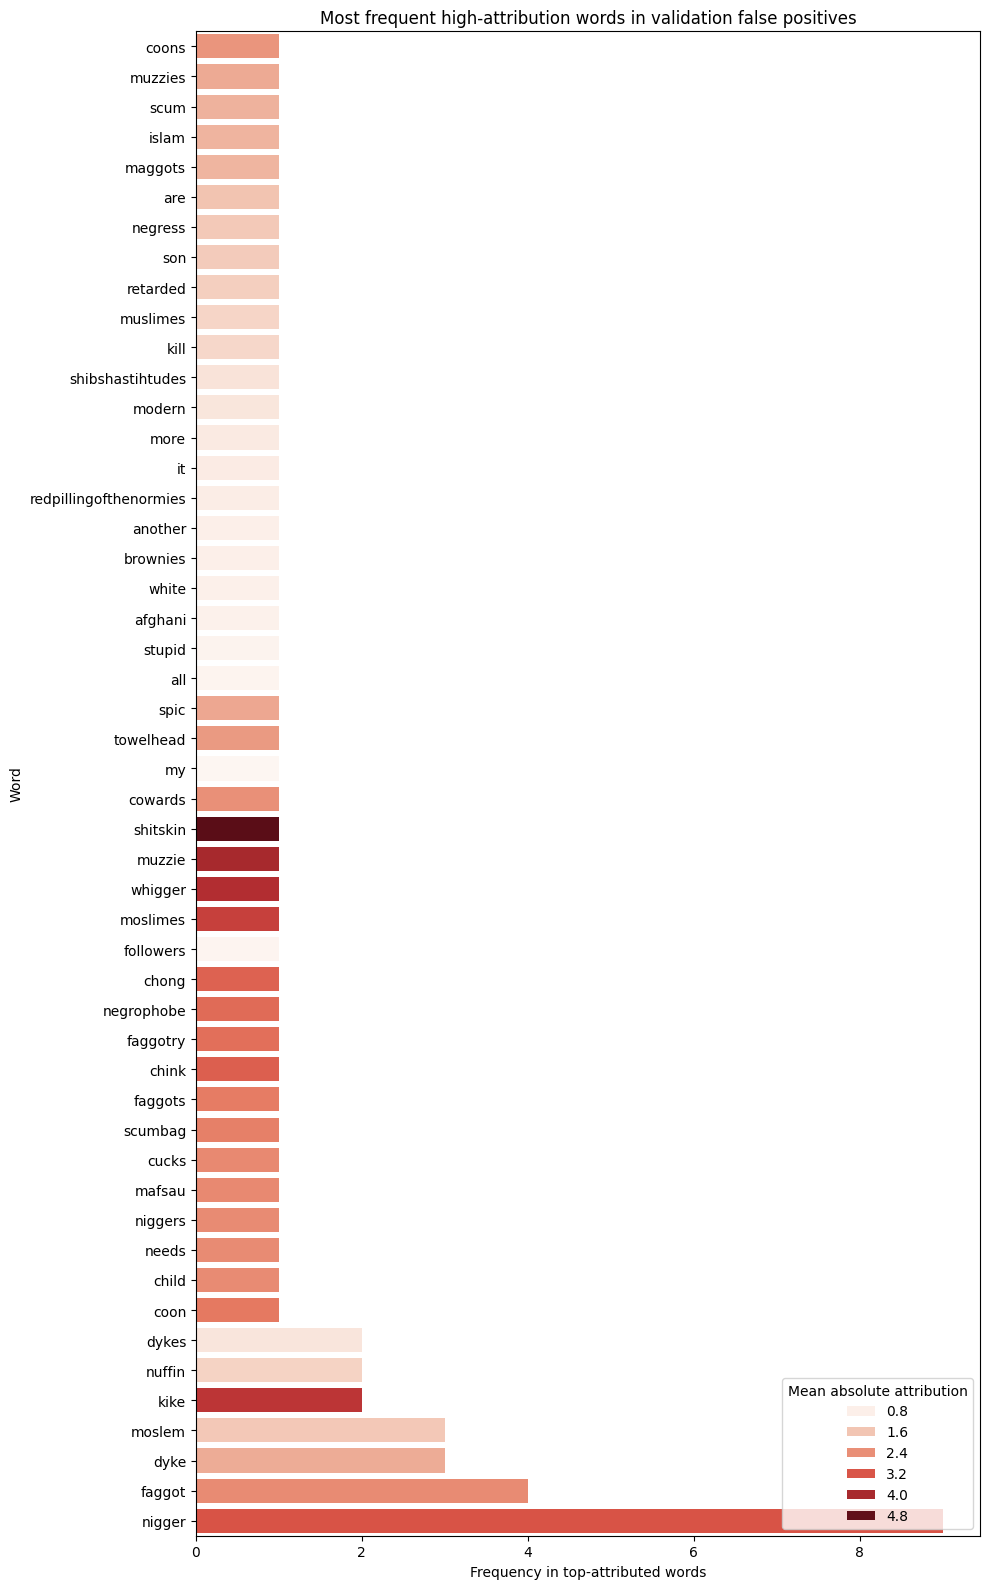

,word,top_k_count,mean_abs_score_when_top_k
0,nigger,9,3.238669
1,faggot,4,2.442068
2,dyke,3,1.960693
3,moslem,3,1.543665
4,kike,2,3.703378
5,nuffin,2,1.388839
6,dykes,2,1.073779
7,shitskin,1,4.877833
8,muzzie,1,4.024399
9,whigger,1,3.844386


In [16]:
# Plot the most frequent and high-attribution reconstructed words from the latest attribution run.
import matplotlib.pyplot as plt
import seaborn as sns

N_TOP_WORDS = 50

top_words_path = RUN_DIR / "top_attributed_words.csv"

if not top_words_path.exists():
    print("No top_attributed_words.csv found yet. Run the discovery attribution cell first.")
else:
    top_words_plot = pd.read_csv(top_words_path)
    required_columns = {"word", "top_k_count", "mean_abs_score_when_top_k"}
    missing_columns = required_columns - set(top_words_plot.columns)

    if missing_columns:
        print(f"Missing columns in {top_words_path}: {sorted(missing_columns)}")
    elif top_words_plot.empty:
        print("top_attributed_words.csv exists, but it is empty.")
    else:
        plot_df = (
            top_words_plot
            .sort_values(["top_k_count", "mean_abs_score_when_top_k"], ascending=False)
            .head(N_TOP_WORDS)
            .sort_values("top_k_count", ascending=True)
        )

        plt.figure(figsize=(10, max(6, 0.32 * len(plot_df))))
        sns.barplot(
            data=plot_df,
            x="top_k_count",
            y="word",
            hue="mean_abs_score_when_top_k",
            palette="Reds",
            dodge=False,
        )
        plt.xlabel("Frequency in top-attributed words")
        plt.ylabel("Word")
        plt.title("Most frequent high-attribution words in validation false positives")
        plt.legend(title="Mean absolute attribution", loc="lower right")
        plt.tight_layout()
        plt.show()

        display(
            plot_df
            .sort_values(["top_k_count", "mean_abs_score_when_top_k"], ascending=False)
            .reset_index(drop=True)
        )


## 8. Extract False Positives for Manual Contrastive Pairs

After reviewing the attribution plot, edit `FINAL_IDENTITY_TERMS` with the identity or trigger terms you want to use. The next cells search all validation false positives from the selected `RUN_DIR`, keep the sentences that contain at least one selected term, and export them as sources for manual contrastive-pair writing.


In [17]:
# Final candidate identity/trigger list from the top 50 attributed words.
# Review this list manually: some entries are true identity terms/slurs, others may be generic triggers or noise.
FINAL_IDENTITY_TERMS = [
    "muslim",
    "jewish",
    "christian",
    "black",
    "white",
    "women",
    "woman",
    "gay",
    "lesbian",
    "trans",
    "immigrant",
    "mexican",
    "asian",
    "arab",
    "disabled",

    "nigger",
    "faggot",
    "moslem",
    "dyke",
    "nuffin",
    "dykes",
    "kike",
    "retarded",
    "afghani",
    "islam",
    "scum",
    "muzzies",
    "shitskin",
    "faggotry",
    "kill",
    "coon",
    "negress",
    "niggers",
    "muslimes",
    "cucks",
    "maggots",
    "whigger",
    "mafsau",
    "scumbag",
    "cowards",
    "jews",
    "white",
    "blacks",
    "brownies",
    "moslimes",
    "child",
    "stupid",
    "muzzie",
    "chong",
    "lads",
    "spic",
    "faggots",
    "negrophobe",
    "coons",
]

FINAL_IDENTITY_TERMS = sorted({term.lower().strip() for term in FINAL_IDENTITY_TERMS if term.strip()})
FINAL_IDENTITY_TERMS


['afghani',
 'arab',
 'asian',
 'black',
 'blacks',
 'brownies',
 'child',
 'chong',
 'christian',
 'coon',
 'coons',
 'cowards',
 'cucks',
 'disabled',
 'dyke',
 'dykes',
 'faggot',
 'faggotry',
 'faggots',
 'gay',
 'immigrant',
 'islam',
 'jewish',
 'jews',
 'kike',
 'kill',
 'lads',
 'lesbian',
 'mafsau',
 'maggots',
 'mexican',
 'moslem',
 'moslimes',
 'muslim',
 'muslimes',
 'muzzie',
 'muzzies',
 'negress',
 'negrophobe',
 'nigger',
 'niggers',
 'nuffin',
 'retarded',
 'scum',
 'scumbag',
 'shitskin',
 'spic',
 'stupid',
 'trans',
 'whigger',
 'white',
 'woman',
 'women']

In [97]:
# Extract all validation false positives that contain at least one selected identity/trigger term.
import re

false_positive_path = RUN_DIR / "validation_false_positives.csv"
manual_pair_output_path = PROJECT_ROOT / "data" / "contrastive" / "false_positives_for_manual_pairs.csv"

def matched_terms_in_text(text, terms):
    text = "" if pd.isna(text) else str(text).lower()
    matched = []
    for term in terms:
        pattern = rf"\b{re.escape(term.lower())}s?\b"
        if re.search(pattern, text):
            matched.append(term)
    return matched

if not false_positive_path.exists():
    print(f"No false-positive file found at {false_positive_path}. Run extract_false_positives.py first.")
elif not FINAL_IDENTITY_TERMS:
    print("FINAL_IDENTITY_TERMS is empty. Add terms before running this cell.")
else:
    false_positives = pd.read_csv(false_positive_path)
    false_positives["matched_final_identity_terms"] = false_positives["text"].apply(
        lambda text: ",".join(matched_terms_in_text(text, FINAL_IDENTITY_TERMS))
    )

    manual_sources = false_positives[
        false_positives["matched_final_identity_terms"].astype(bool)
    ].copy()

    manual_sources = manual_sources.sort_values(
        by=["prob_hateful", "matched_final_identity_terms"],
        ascending=[False, True],
    )

    manual_sources["hateful_counterpart"] = ""
    manual_sources["pair_notes"] = ""

    preferred_columns = [
        "id",
        "text",
        "gold_label",
        "pred_label",
        "prob_hateful",
        "matched_final_identity_terms",
        "identity_terms",
        "has_identity_term",
        "hateful_counterpart",
        "pair_notes",
    ]
    existing_columns = [column for column in preferred_columns if column in manual_sources.columns]
    remaining_columns = [column for column in manual_sources.columns if column not in existing_columns]
    manual_sources = manual_sources[existing_columns + remaining_columns]

    manual_pair_output_path.parent.mkdir(parents=True, exist_ok=True)
    manual_sources.to_csv(manual_pair_output_path, index=False)

    print(f"Selected {len(manual_sources)} / {len(false_positives)} validation false positives.")
    print(f"Saved manual-pair source file to: {manual_pair_output_path}")
    display(manual_sources)


Selected 64 / 71 validation false positives.
Saved manual-pair source file to: /Users/mahe/Desktop/EPFL/MA4/deep learning/Deep_Learning_hate_speech_detection-1/data/contrastive/false_positives_for_manual_pairs.csv


,id,text,gold_label,pred_label,prob_hateful,matched_final_identity_terms,identity_terms,has_identity_term,hateful_counterpart,pair_notes,label,label_id,prob_non_hateful
31,10413780_gab,the muslimes and africans want to take over al...,non_hateful,hateful,0.998419,"muslimes,white,women","white,women",True,,,non_hateful,0,0.001581
33,24193157_gab,how much longer will the west continue to put ...,non_hateful,hateful,0.997996,"cucks,retarded",NaN,False,,,non_hateful,0,0.002005
12,22206778_gab,cowardly brit pray for death rather than drive...,non_hateful,hateful,0.997917,moslem,NaN,False,,,non_hateful,0,0.002083
22,27106705_gab,i am the reaction to the shitskin invasion,non_hateful,hateful,0.997821,shitskin,NaN,False,,,non_hateful,0,0.002179
29,25873026_gab,it seems to me that the ideal queen for great ...,non_hateful,hateful,0.997583,"lesbian,negress",lesbian,True,,,non_hateful,0,0.002416
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,22320605_gab,guise i just want to remind all you haters tha...,non_hateful,hateful,0.635332,black,black,True,,,non_hateful,0,0.364668
18,11800347_gab,by running away and proclaiming victory in his...,non_hateful,hateful,0.594408,white,white,True,,,non_hateful,0,0.405592
25,1179007106646708224_twitter,<user> shit i need a flamethrower 😂 kill all t...,non_hateful,hateful,0.558441,kill,NaN,False,,,non_hateful,0,0.441559
34,1179105723831050240_twitter,i was talking to a co worker about the local t...,non_hateful,hateful,0.520186,"faggot,faggots,kill,maggots",NaN,False,,,non_hateful,0,0.479814


In [19]:
# Count how often each selected term appears in the extracted false-positive sources.
if "manual_sources" not in globals() or manual_sources.empty:
    print("No manual-pair sources available yet.")
else:
    term_rows = []
    for _, row in manual_sources.iterrows():
        for term in str(row["matched_final_identity_terms"]).split(","):
            if term:
                term_rows.append({"term": term, "id": row["id"]})

    term_summary = (
        pd.DataFrame(term_rows)
        .groupby("term")
        .size()
        .reset_index(name="false_positive_count")
        .sort_values("false_positive_count", ascending=False)
    )
    display(term_summary)


,term,false_positive_count
36,nigger,10
46,white,9
28,moslem,7
14,faggot,7
3,black,6
12,dyke,6
39,retarded,5
23,kill,4
13,dykes,3
17,gay,3


## 9. Contrastive Training

The completed manual dataset is stored in `data/contrastive/contrastive_pairs_completed.csv`. The notebook only validates the pair file and keeps one small local smoke test to check that the training code runs.

The full hyperparameter grid was trained on the EPFL RCP cluster, not from this notebook. Those completed runs are analyzed from their saved CSV and JSON outputs in the following sections.


In [96]:
# Inspect the completed contrastive pair file.
PAIR_FILE_COMPLETED = PROJECT_ROOT / "data" / "contrastive" / "contrastive_pairs_completed.csv"

if not PAIR_FILE_COMPLETED.exists():
    print(f"Missing completed pair file: {PAIR_FILE_COMPLETED}")
else:
    completed_pairs = pd.read_csv(PAIR_FILE_COMPLETED)
    required_pair_columns = {"non_hateful_text", "hateful_counterpart"}
    missing_pair_columns = required_pair_columns - set(completed_pairs.columns)

    if missing_pair_columns:
        print(f"Missing columns in completed pair file: {sorted(missing_pair_columns)}")
    else:
        non_empty_non_hateful = completed_pairs["non_hateful_text"].fillna("").astype(str).str.strip().ne("")
        non_empty_hateful = completed_pairs["hateful_counterpart"].fillna("").astype(str).str.strip().ne("")
        usable_pairs = completed_pairs[non_empty_non_hateful & non_empty_hateful].copy()
        print(f"Completed pair rows: {len(completed_pairs)}")
        print(f"Usable pair rows: {len(usable_pairs)}")
        print(f"Training pair file: {PAIR_FILE_COMPLETED}")
        display(
            usable_pairs[[
                column for column in [
                    "pair_id",
                    "source_false_positive_id",
                    "matched_final_identity_terms",
                    "prob_hateful_baseline",
                ]
                if column in usable_pairs.columns
            ]].head(20)
        )


Completed pair rows: 128
Usable pair rows: 128
Training pair file: /Users/mahe/Desktop/EPFL/MA4/deep learning/Deep_Learning_hate_speech_detection-1/data/contrastive/contrastive_pairs_completed.csv


,pair_id,source_false_positive_id,matched_final_identity_terms,prob_hateful_baseline
0,pair_0001,10413780_gab,"muslimes,white,women",0.998419
1,pair_0002,10413780_gab,"muslimes,white,women",0.998419
2,pair_0003,24193157_gab,"cucks,retarded",0.997996
3,pair_0004,24193157_gab,"cucks,retarded",0.997996
4,pair_0005,22206778_gab,moslem,0.997917
5,pair_0006,22206778_gab,moslem,0.997917
6,pair_0007,27106705_gab,shitskin,0.997821
7,pair_0008,27106705_gab,shitskin,0.997821
8,pair_0009,25873026_gab,"lesbian,negress",0.997583
9,pair_0010,25873026_gab,"lesbian,negress",0.997583


In [ ]:
# Optional local smoke test. This uses small subsets and a short partial epoch.
# !python src/train_contrastive.py \
#   --init-model-dir "{RUN_DIR / 'best_model'}" \
#   --pair-file "{PAIR_FILE_COMPLETED}" \
#   --non-hateful-column non_hateful_text \
#   --hateful-column hateful_counterpart \
#   --quick --quick-size 64 --quick-pairs 8 \
#   --epochs 0.05 --batch-size 8 --pair-batch-size 4 \
#   --alpha 0.1 --beta 0.5 --margin 18 \
#   --run-tag smoke_contrastive_check


## 10. Grid-Search Analysis

The cluster grid-search results are consolidated by `src/analyze_grid_search.py`. The script combines the baseline, grid summaries, and available completed run folders, then removes duplicate hyperparameter settings. Test recall and macro-F1 are retained as guardrails when comparing identity false positives.

In [ ]:
# ── 1. SUBMIT THE GRID (run from the cluster jumphost) ──────────────────────────
#
# for MARGIN in 1 5 10 15 18 20 22; do
#   for ALPHA in 0.05 0.10 0.20 0.50 1.0 2.0 5.0; do
#     for BETA in 0.00 0.05 0.10 0.20 0.50 1.0; do
#       runai submit "contrastive-m${MARGIN}-a${ALPHA}-b${BETA}" \
#         --image registry.rcp.epfl.ch/ee559/environment-with-packages:latest \
#         --gpu 1 \
#         --command -- python3 src/train_contrastive.py \
#           --alpha  "${ALPHA}" \
#           --beta   "${BETA}"  \
#           --margin "${MARGIN}"
#     done
#   done
# done
#
# ── 2. MONITOR ───────────────────────────────────────────────────────────────────
#
# runai list
# runai logs <job-name>
#
# ── 3. RETRIEVE RESULTS (run from your local Mac terminal) ───────────────────────
#
# Grid metrics only — no model weights (all 208 runs):
#   scp -r velay@jumphost.rcp.epfl.ch:<grid-results-dir>/ outputs/contrastive/
#
# Full checkpoint for the two attribution models:
#   scp -r velay@jumphost.rcp.epfl.ch:<attribution-results-dir>/balanced_m18  \
#     outputs/contrastive/balanced_for_attribution_m18_a0p2_b0p05
#   scp -r velay@jumphost.rcp.epfl.ch:<attribution-results-dir>/aggressive_m22 \
#     outputs/contrastive/aggressive_for_attribution_m22_a2_b0p5
#
# Then rebuild the consolidated comparison table locally:
#   python src/analyze_grid_search.py --force

In [95]:
# Regenerate only when the source summaries change. --force permits overwriting the final CSV.
# !python src/analyze_grid_search.py --force

comparison_path = PROJECT_ROOT / "outputs" / "contrastive" / "all_model_comparison_clean.csv"
all_models = pd.read_csv(comparison_path)

selected = all_models[
    (all_models["source"] == "baseline_run")
    | (
        (all_models["margin"] == 18)
        & (all_models["alpha"] == 0.2)
        & (all_models["beta"] == 0.05)
    )
    | (
        (all_models["margin"] == 22)
        & (all_models["alpha"] == 2.0)
        & (all_models["beta"] == 0.5)
    )
]
display(selected[[
    "run_name", "margin", "alpha", "beta", "test_macro_f1",
    "test_precision_hateful", "test_recall_hateful",
    "test_false_positives", "test_identity_false_positives",
]])

,run_name,margin,alpha,beta,test_macro_f1,test_precision_hateful,test_recall_hateful,test_false_positives,test_identity_false_positives
0,baseline_run1,NaN,NaN,NaN,0.894796,0.881757,0.878788,70,26
49,alpha0p2_beta0p05_margin18_run1,18.0,0.2,0.05,0.891414,0.890244,0.860269,63,22
208,margin22_alpha2p00_beta0p50,22.0,2.0,0.50,0.887449,0.912639,0.826599,47,17


## 11. Attribution Shift Analysis

This analysis compares the baseline, balanced, and aggressive models on the 14 identity false positives shared by all three. By default, the script reuses the saved Integrated Gradients outputs and only rebuilds the summary tables.

Recomputing attribution is explicit and expensive: run `python src/analyze_attribution_shift.py --run-attribution --force` only when needed.

In [94]:
# Rebuild cached summaries only when needed.
# !python src/analyze_attribution_shift.py --force

attribution_summary = pd.read_csv(
    PROJECT_ROOT / "outputs" / "attribution_comparison" / "identity_attribution_share_summary.csv"
)
display(attribution_summary)

,model,examples,mean_identity_share,median_identity_share,std_identity_share,mean_identity_abs,mean_total_abs
0,aggressive_reduction,14,0.315225,0.344351,0.157590,1.364936,4.634004
1,balanced_guardrail,14,0.348935,0.359633,0.177977,1.993967,5.885631
2,baseline,14,0.368443,0.383445,0.207634,2.120925,5.975795


## 12. False-Negative Guardrail

Reduced identity false positives are useful only if the model still detects genuinely hateful identity-related examples. This section measures total and identity false negatives for the baseline, balanced, and aggressive models, including per-term hateful recall.

In [90]:
# Rebuild cached summaries only when needed.
# !python src/analyze_false_negatives.py --force

false_negative_summary = pd.read_csv(
    PROJECT_ROOT / "outputs" / "false_negative_analysis" / "false_negative_summary_by_model.csv"
)
display(false_negative_summary)

,model,total_hateful_examples,total_false_negatives,total_hateful_recall,identity_hateful_examples,identity_false_negatives,identity_hateful_recall
0,baseline,594,72,0.878788,527,59,0.888046
1,balanced_guardrail,594,83,0.860269,527,67,0.872865
2,aggressive_reduction,594,103,0.826599,527,87,0.834915


### 12.1 Final Analysis Plots

All plots for the grid search, attribution shift, and false-negative guardrail are generated from saved CSV files by one plotting script.

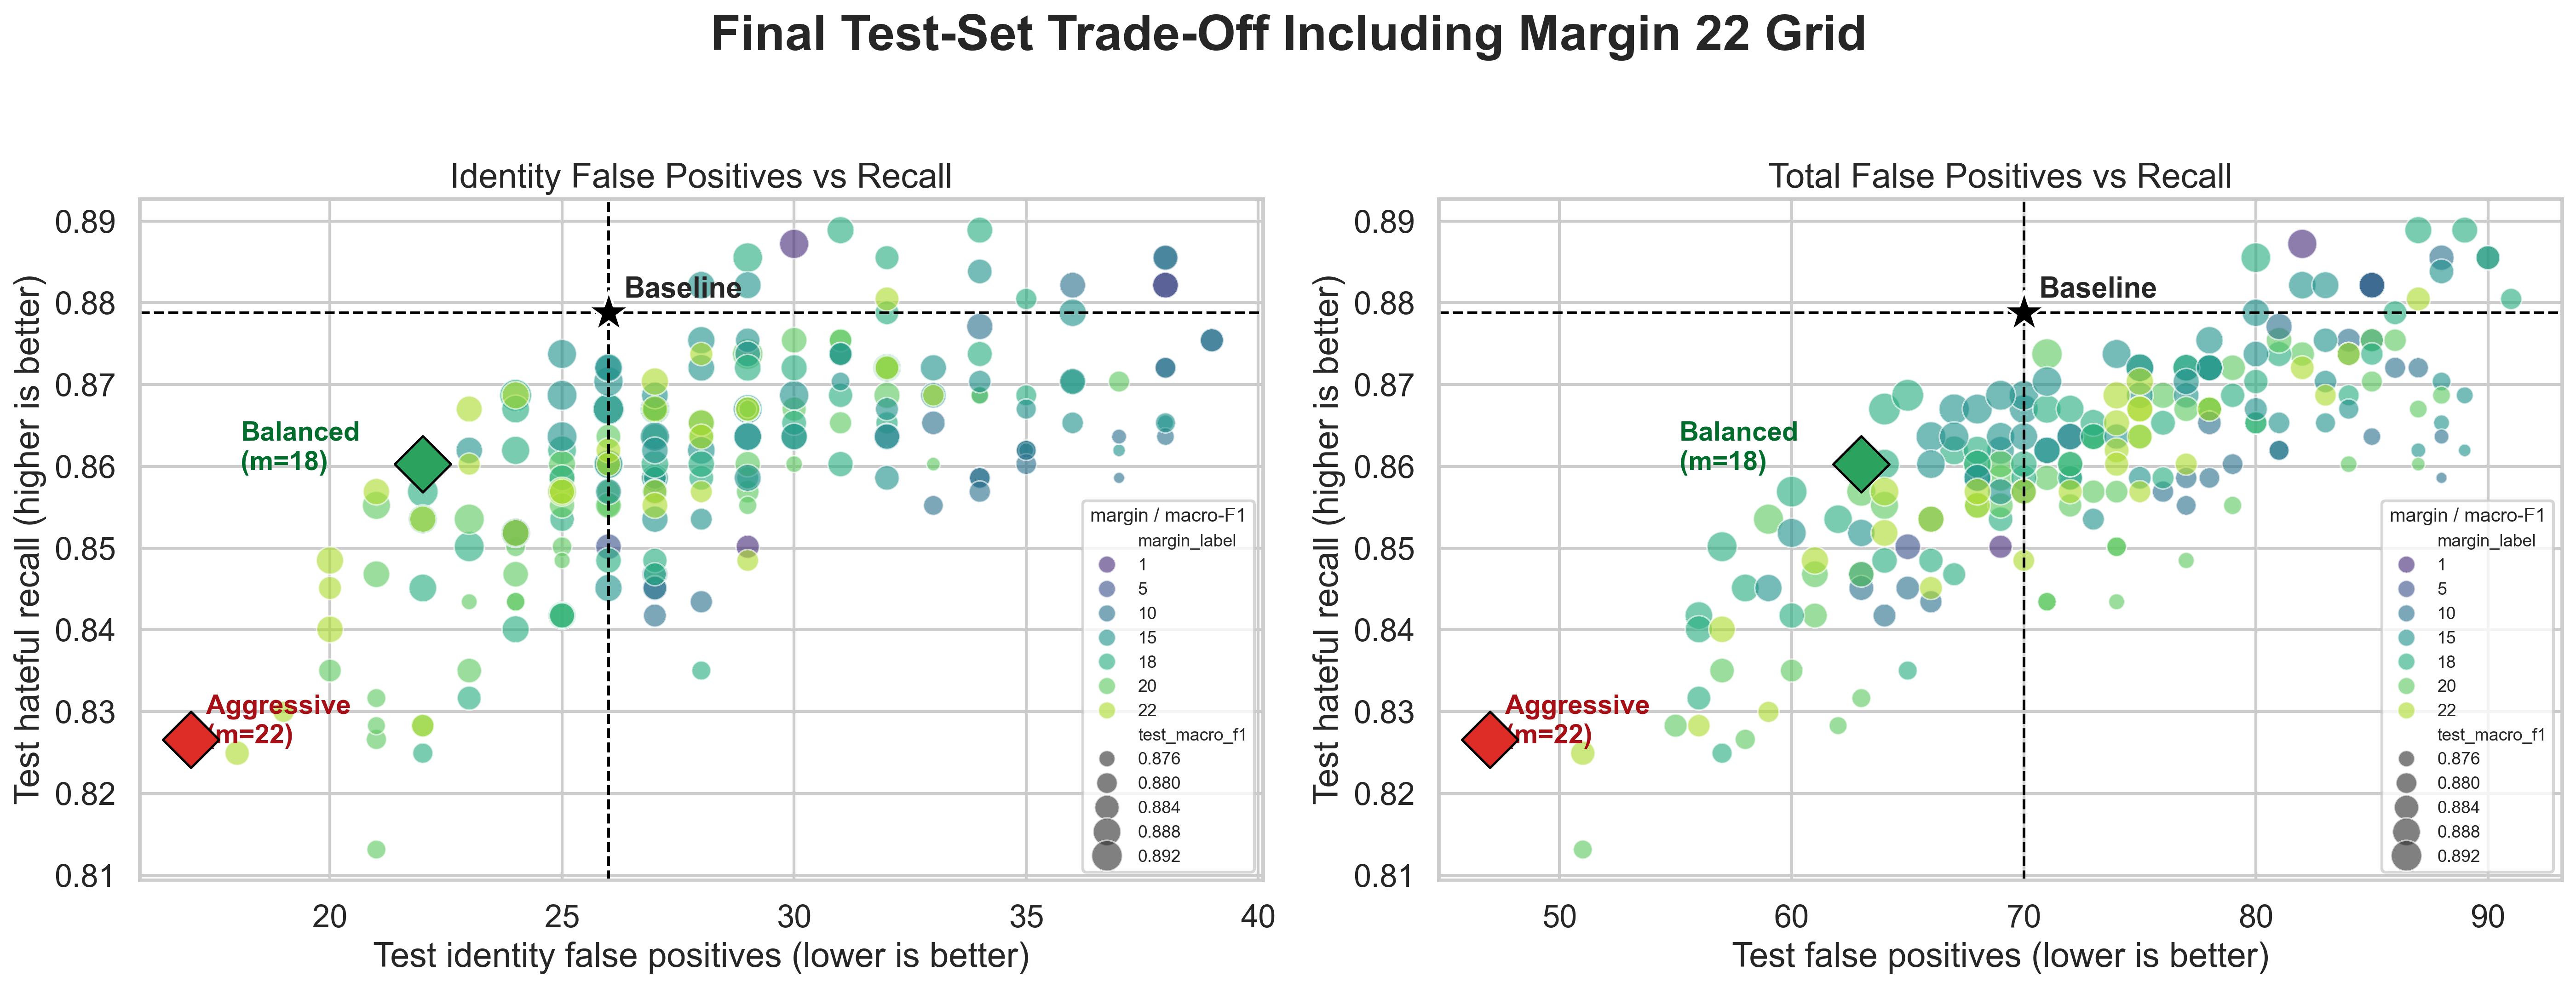

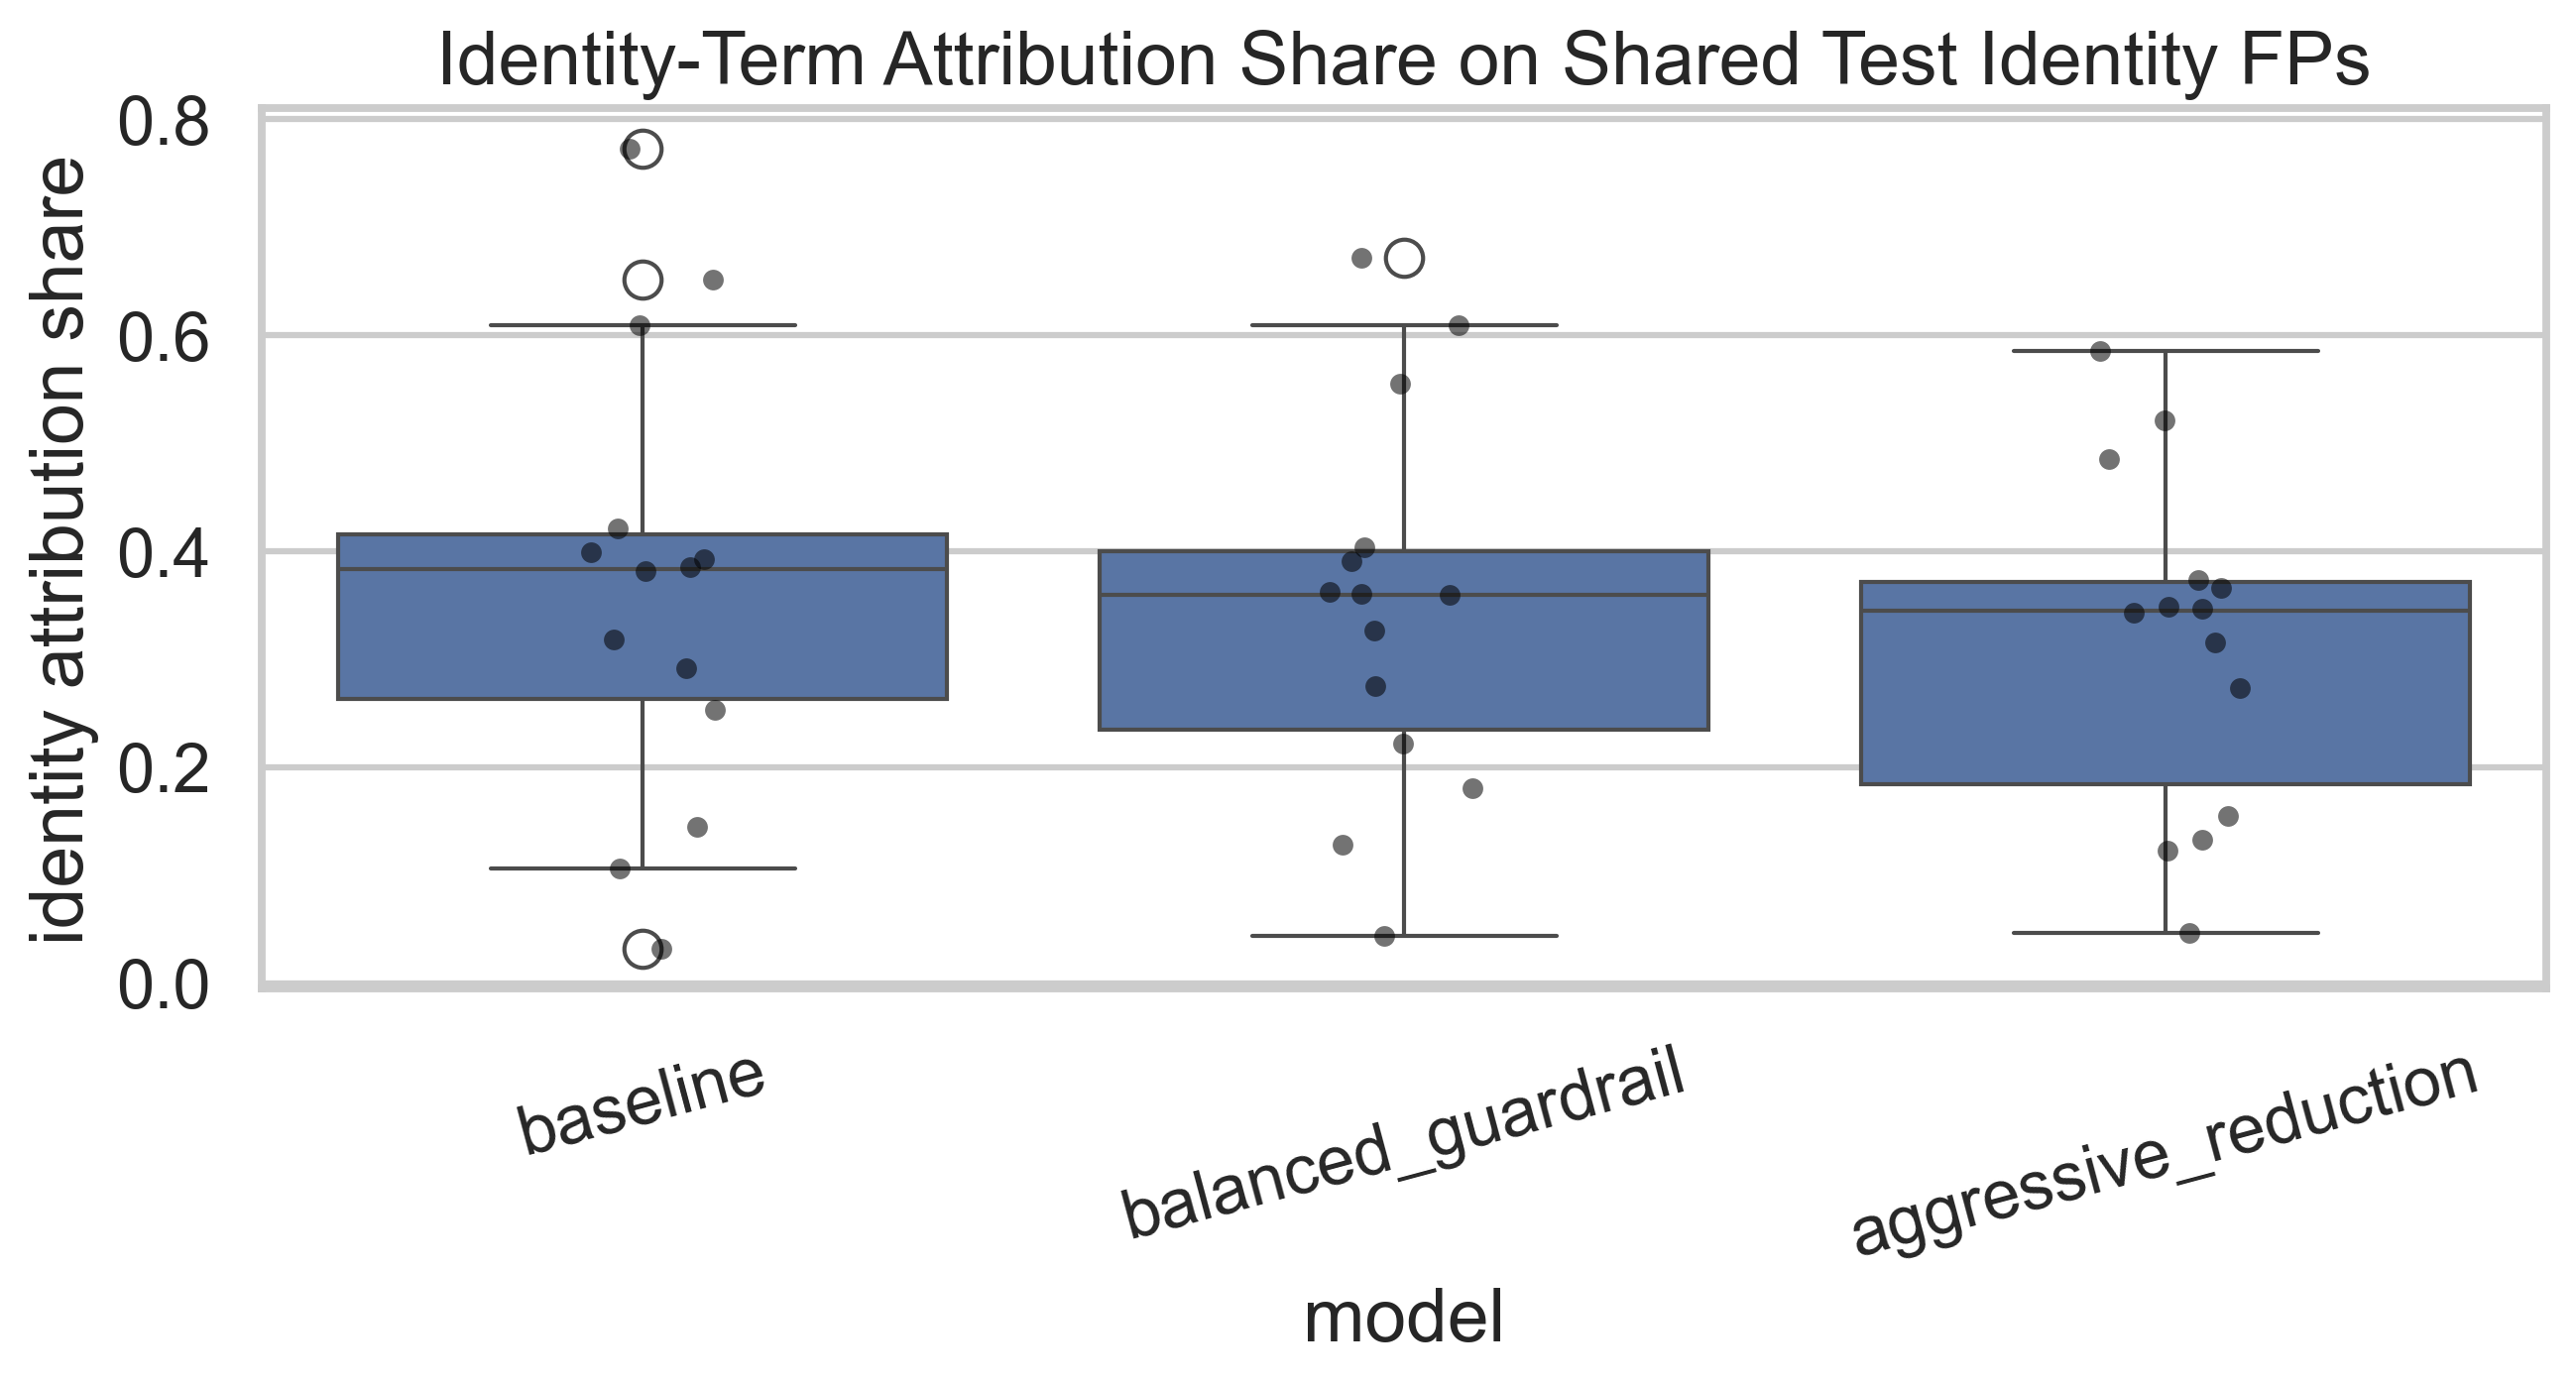

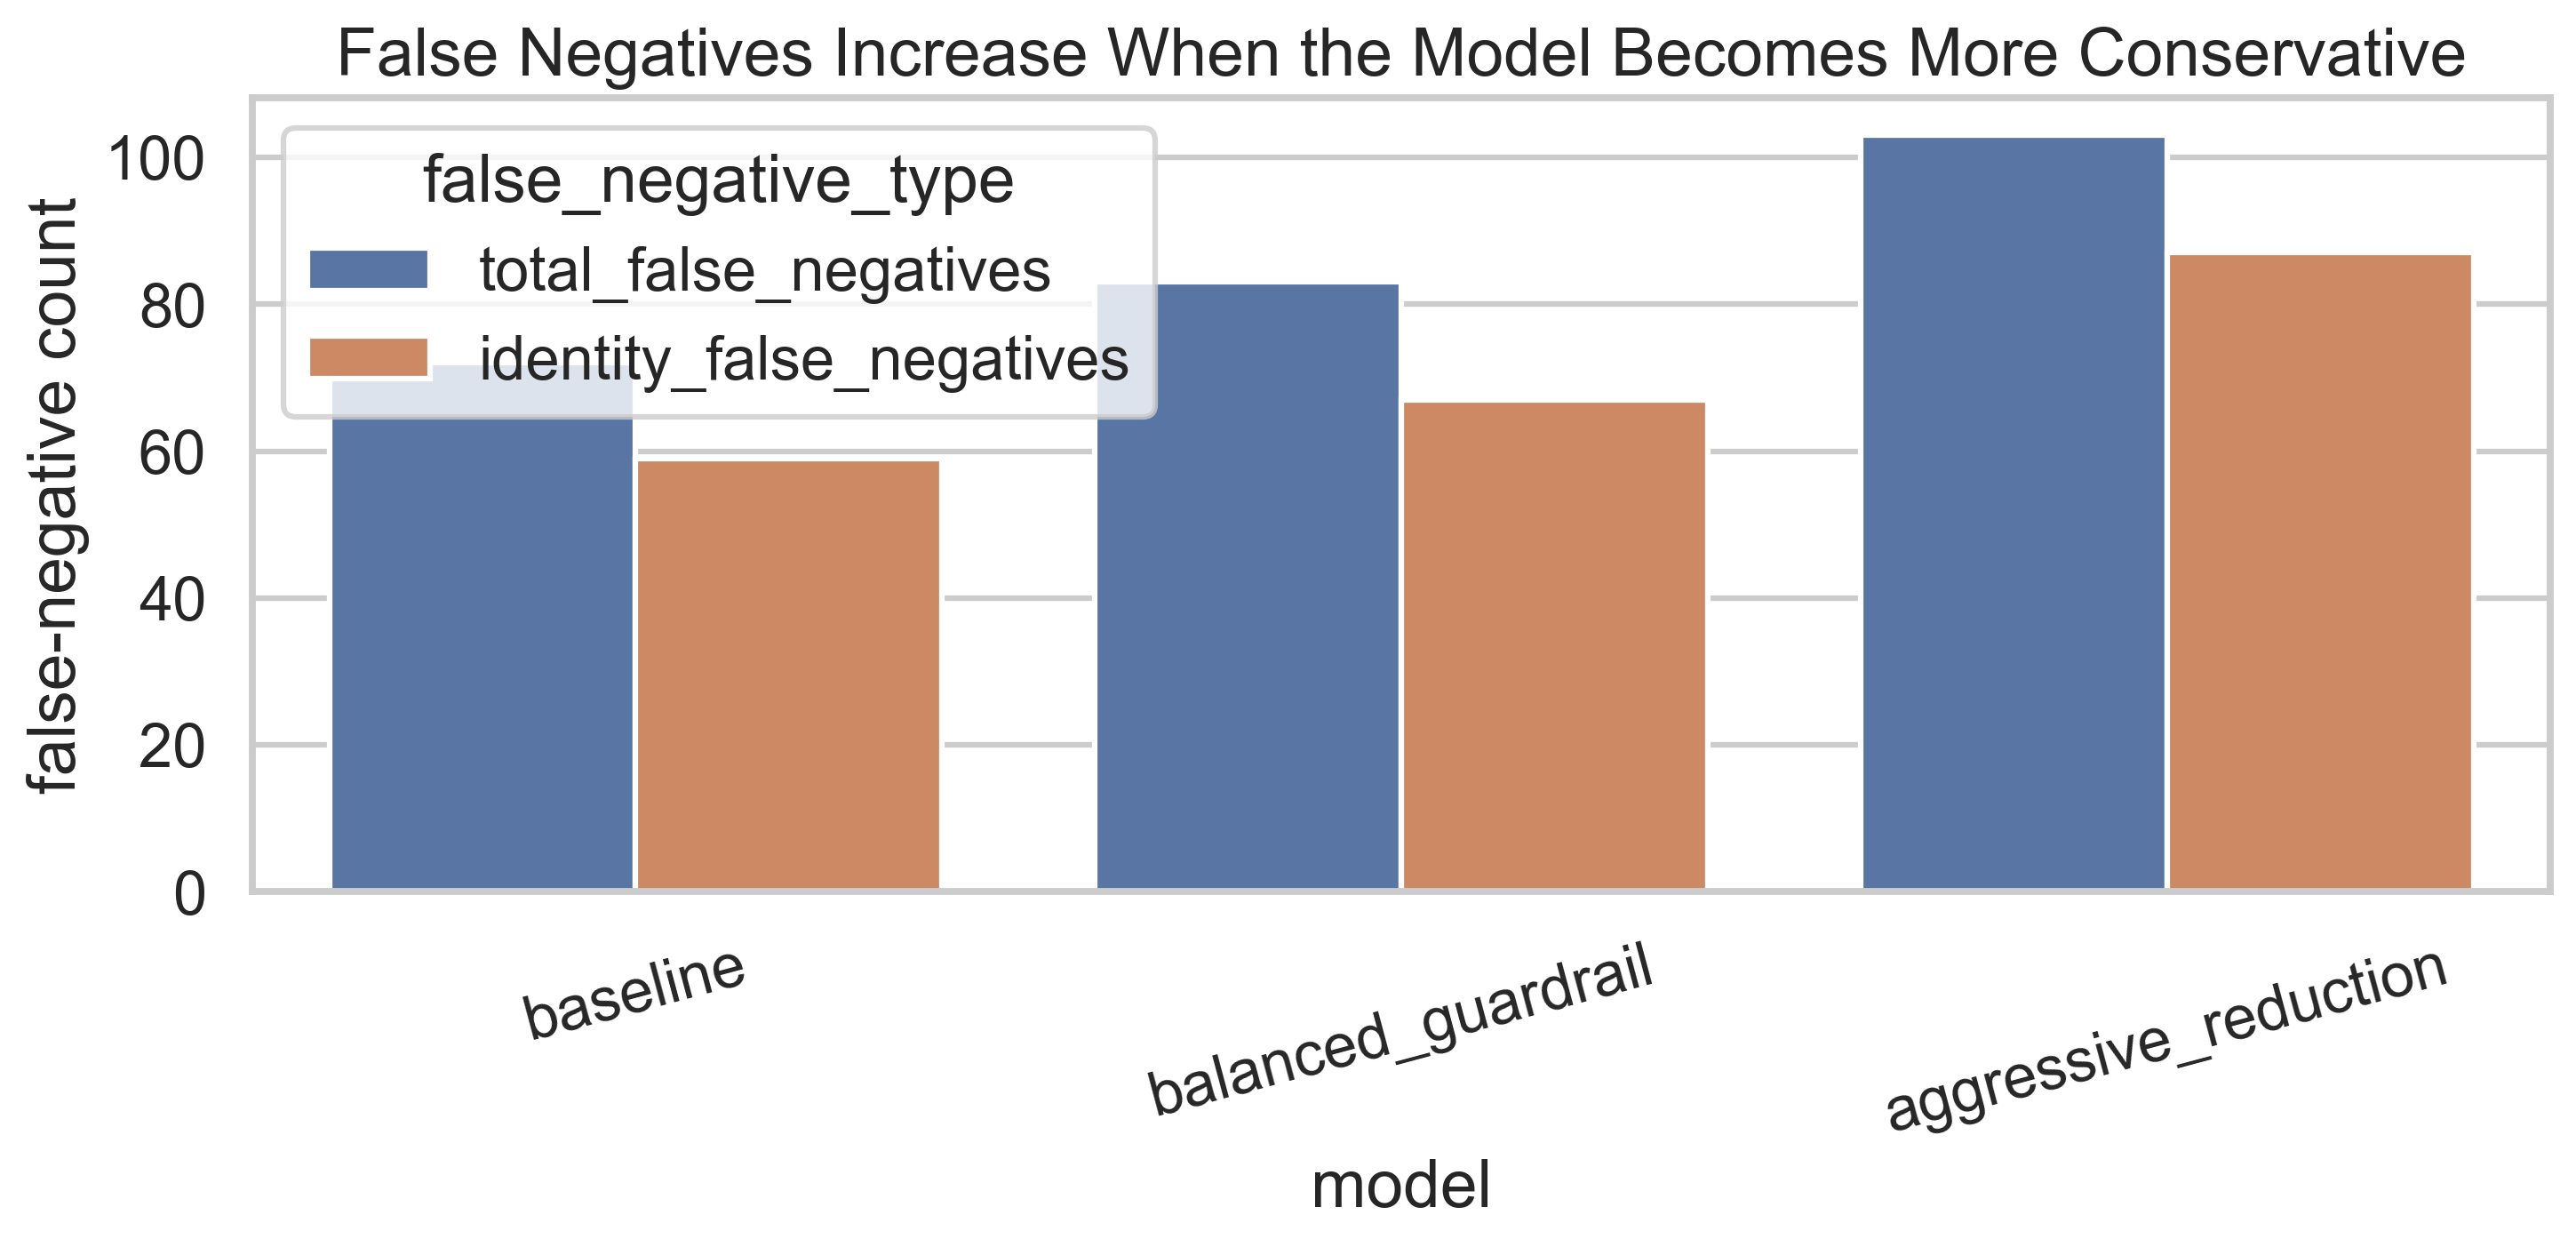

In [91]:
# Regenerate existing figures only when needed.
# !python src/plot_final_analysis.py --force

from IPython.display import Image, display

display(Image(filename=str(PROJECT_ROOT / "outputs" / "plots" / "final_tradeoff_scatter_with_margin22.png")))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "attribution_comparison" / "identity_attribution_share_boxplot.png")))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "false_negative_analysis" / "false_negative_counts_by_model.png")))


## 13. Attribution Specificity: Identity Terms vs Context Words

This analysis divides each reconstructed word's **absolute Integrated Gradients attribution** into three buckets:

1. **Identity / selected trigger**: the word matches the first vocabulary. This vocabulary combines the original identity seed terms from `src/inspect_hatexplain.py`, terms recorded during contrastive-candidate construction, and manually added aliases or slurs.
2. **Non-identity hateful context**: the word does not match the first vocabulary but matches a manually defined context vocabulary for violence, exclusion, dehumanization, threats, or hostile generalization. Examples include `deport`, `inferior`, `threat`, and `genocide`.
3. **Other**: every word not assigned to the first two buckets, including stopwords, neutral content words, and meaningful words missing from the context vocabulary.

Words are lowercased and punctuation is removed before matching. Exact vocabulary matches are preferred; conservative substring matching is allowed only when both strings contain at least four characters. Identity matching is performed before context matching, so a word cannot belong to both categories.

For each sentence, the absolute attribution scores are summed within each bucket and divided by the total absolute attribution:

`bucket share = bucket absolute attribution / total absolute attribution`

The method is vocabulary-based. In particular, `other` does not mean semantically irrelevant or neutral; it only means that the word was not covered by the two manually defined vocabularies.

A limitation of the existing analysis is that the candidate-construction vocabulary contains some generic triggers, such as `kill`, in addition to identity terms. Because the first vocabulary has priority, such a word is assigned to the identity / selected-trigger bucket rather than the context bucket. The saved final results use this original rule, so the standalone function preserves it for reproducibility.

In [92]:
from src.analyze_attribution_specificity import (
    build_identity_vocabulary,
    classify_attribution_word,
)

identity_vocabulary = build_identity_vocabulary(
    PROJECT_ROOT / "data" / "contrastive" / "false_positives_for_manual_pairs.csv"
)

example_words = ["Muslim", "women", "kill", "deported", "advocacy", "the"]
bucket_examples = pd.DataFrame({
    "word": example_words,
    "bucket": [
        classify_attribution_word(word, identity_vocabulary)
        for word in example_words
    ],
})
display(bucket_examples)

,word,bucket
0,Muslim,identity
1,women,identity
2,kill,identity
3,deported,non_identity_hateful_context
4,advocacy,other
5,the,other


### 13.1 Saved Specificity Results

The full implementation is in `src/analyze_attribution_specificity.py`. The notebook loads the existing final CSVs. Integrated Gradients is recomputed only with the explicit command:

`python src/analyze_attribution_specificity.py --run-attribution --force`

In [93]:
# Rebuild summary tables from cached attribution only when needed.
# !python src/analyze_attribution_specificity.py --force

specificity_summary = pd.read_csv(
    PROJECT_ROOT / "outputs" / "attribution_specificity" / "attribution_specificity_summary.csv"
)
display(specificity_summary)

,analysis_subset,model,identity_share,context_share,other_share
0,baseline_identity_fp_resolved_by_aggressive,aggressive_reduction,0.179088,0.022443,0.798469
1,baseline_identity_fp_resolved_by_aggressive,balanced_guardrail,0.231759,0.011012,0.757229
2,baseline_identity_fp_resolved_by_aggressive,baseline,0.271970,0.013480,0.714550
3,common_correct_identity_hateful,aggressive_reduction,0.284034,0.019148,0.696818
4,common_correct_identity_hateful,balanced_guardrail,0.322920,0.032697,0.644383
5,common_correct_identity_hateful,baseline,0.367987,0.020211,0.611802
6,common_identity_fp_all_models,aggressive_reduction,0.239645,0.012363,0.747992
7,common_identity_fp_all_models,balanced_guardrail,0.297269,0.013809,0.688922
8,common_identity_fp_all_models,baseline,0.329626,0.012912,0.657462
